Dados de entrada:
x = [0 1 2 3 4 5]
y = [1.  2.  1.  0.5 4.  8. ]

=== INTERPOLAÇÃO POLINOMIAL ===
Coeficientes do polinômio: [ 1.          0.98333333  1.54166667 -2.16666667  0.70833333 -0.06666667]

=== SPLINE CÚBICA NATURAL ===
Coeficientes das splines:
Segmento 0: a=1.0000, b=1.4976, c=0.0000, d=-0.4976
Segmento 1: a=2.0000, b=0.0048, c=-1.4928, d=0.4880
Segmento 2: a=1.0000, b=-1.5167, c=-0.0287, d=1.0455
Segmento 3: a=0.5000, b=1.5622, c=3.1077, d=-1.1699
Segmento 4: a=4.0000, b=4.2679, c=-0.4019, d=0.1340


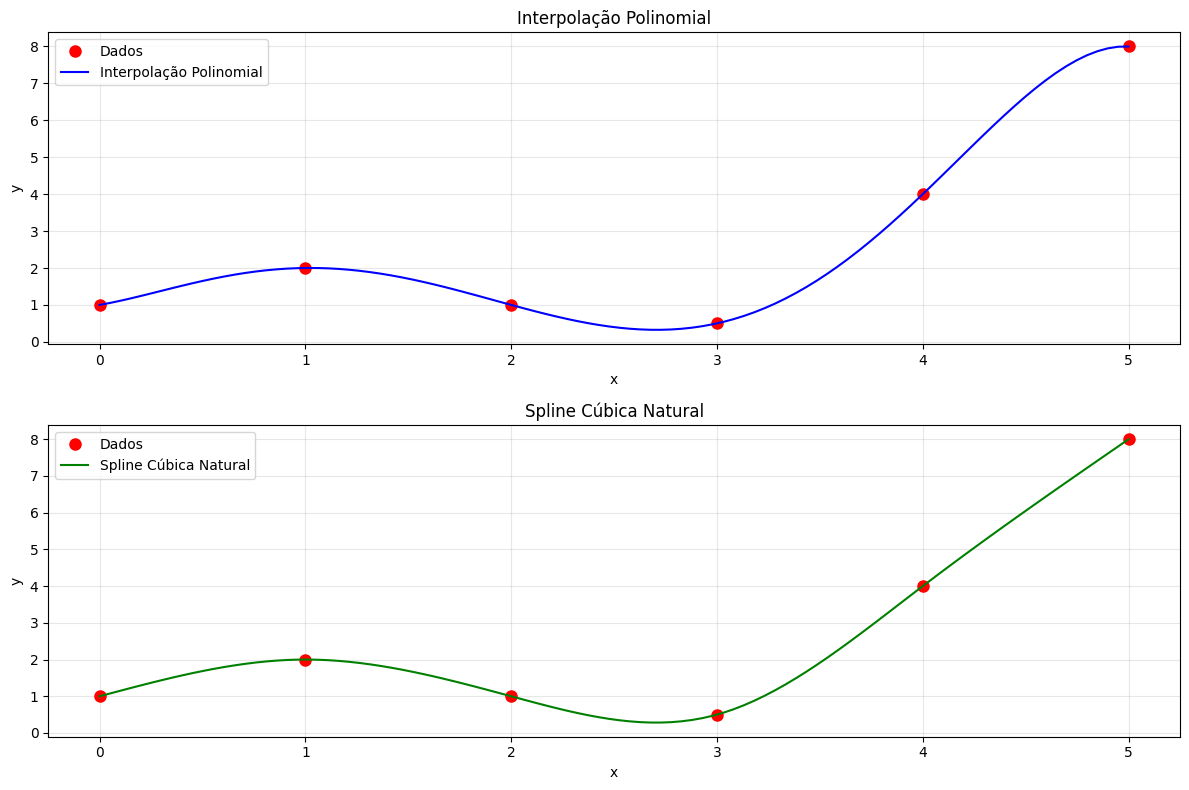


=== AVALIAÇÃO EM PONTOS ESPECÍFICOS ===
Pontos de teste: [0.5 1.5 2.5 3.5 4.5]
Interpolação Polinomial: [1.6484375 1.7109375 0.3984375 1.7109375 6.6484375]
Spline Cúbica: [1.68660287 1.69019139 0.36513158 1.9117823  6.05023923]


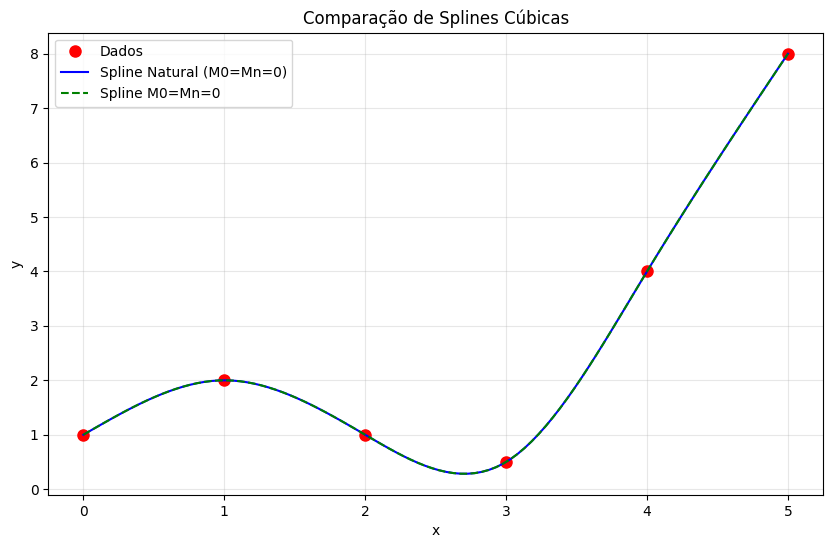

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def interpolacao_polinomial(x, y):
    """
    Calcula o polinômio interpolador usando sistemas lineares

    Parâmetros:
    x: array com os pontos x conhecidos
    y: array com os valores y conhecidos

    Retorna:
    coeficientes: coeficientes do polinômio interpolador (a0 + a1*x + a2*x² + ...)
    """
    n = len(x)

    # Construir a matriz de Vandermonde
    A = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            A[i, j] = x[i] ** j

    # Resolver o sistema linear A * coeficientes = y
    coeficientes = np.linalg.solve(A, y)

    return coeficientes

def avaliar_polinomio(coeficientes, x_avaliar):
    """
    Avalia o polinômio nos pontos x_avaliar

    Parâmetros:
    coeficientes: coeficientes do polinômio
    x_avaliar: pontos onde avaliar o polinômio

    Retorna:
    y_avaliar: valores do polinômio nos pontos x_avaliar
    """
    n = len(coeficientes)
    y_avaliar = np.zeros_like(x_avaliar)

    for i in range(n):
        y_avaliar += coeficientes[i] * (x_avaliar ** i)

    return y_avaliar

def spline_cubica(x, y, condicoes_naturais=True):
    """
    Calcula splines cúbicas naturais ou com derivadas segundas nulas nas extremidades

    Parâmetros:
    x: array com os pontos x conhecidos
    y: array com os valores y conhecidos
    condicoes_naturais: True para splines naturais (M0 = Mn = 0), False para M0 = Mn = 0

    Retorna:
    splines: lista de coeficientes para cada segmento [a, b, c, d]
    """
    n = len(x) - 1  # número de segmentos

    # Passo 1: Calcular h_i
    h = np.diff(x)

    # Passo 2: Construir o sistema para M (derivadas segundas)
    # Sistema: A * M = b

    # Matriz A (tridiagonal)
    A = np.zeros((n+1, n+1))
    b = np.zeros(n+1)

    # Condições de continuidade das derivadas segundas
    for i in range(1, n):
        A[i, i-1] = h[i-1] / 6
        A[i, i] = (h[i-1] + h[i]) / 3
        A[i, i+1] = h[i] / 6
        b[i] = (y[i+1] - y[i]) / h[i] - (y[i] - y[i-1]) / h[i-1]

    # Condições de contorno
    if condicoes_naturais:
        # Spline natural: M0 = 0, Mn = 0
        A[0, 0] = 1
        A[n, n] = 1
        b[0] = 0
        b[n] = 0
    else:
        # Derivadas segundas nulas nas extremidades
        A[0, 0] = 1
        A[n, n] = 1
        b[0] = 0
        b[n] = 0

    # Resolver para M
    M = np.linalg.solve(A, b)

    # Passo 3: Calcular coeficientes para cada segmento
    splines = []
    for i in range(n):
        a = y[i]
        b = (y[i+1] - y[i]) / h[i] - h[i] * (2*M[i] + M[i+1]) / 6
        c = M[i] / 2
        d = (M[i+1] - M[i]) / (6 * h[i])

        splines.append([a, b, c, d])

    return splines, x

def avaliar_spline(splines, x_original, x_avaliar):
    """
    Avalia a spline cúbica nos pontos x_avaliar

    Parâmetros:
    splines: lista de coeficientes das splines
    x_original: pontos x originais
    x_avaliar: pontos onde avaliar a spline

    Retorna:
    y_avaliar: valores da spline nos pontos x_avaliar
    """
    y_avaliar = np.zeros_like(x_avaliar)

    for i, x_val in enumerate(x_avaliar):
        # Encontrar o segmento correto
        for j in range(len(splines)):
            if x_original[j] <= x_val <= x_original[j+1]:
                h = x_val - x_original[j]
                a, b, c, d = splines[j]
                y_avaliar[i] = a + b*h + c*h**2 + d*h**3
                break
        else:
            # Extrapolação - usar o primeiro ou último segmento
            if x_val < x_original[0]:
                h = x_val - x_original[0]
                a, b, c, d = splines[0]
                y_avaliar[i] = a + b*h + c*h**2 + d*h**3
            else:
                h = x_val - x_original[-2]
                a, b, c, d = splines[-1]
                y_avaliar[i] = a + b*h + c*h**2 + d*h**3

    return y_avaliar

# Teste com os dados do exemplo
def testar_interpolacao():
    """
    Testa as funções de interpolação com os dados do exemplo
    """
    # Dados do exemplo do Python Numerical Methods
    x_dados = np.array([0, 1, 2, 3, 4, 5])
    y_dados = np.array([1, 2, 1, 0.5, 4, 8])

    print("Dados de entrada:")
    print(f"x = {x_dados}")
    print(f"y = {y_dados}")
    print()

    # Interpolação Polinomial
    print("=== INTERPOLAÇÃO POLINOMIAL ===")
    coef_poli = interpolacao_polinomial(x_dados, y_dados)
    print(f"Coeficientes do polinômio: {coef_poli}")

    # Criar pontos para plotagem
    x_suave = np.linspace(min(x_dados), max(x_dados), 100)
    y_poli = avaliar_polinomio(coef_poli, x_suave)

    # Spline Cúbica
    print("\n=== SPLINE CÚBICA NATURAL ===")
    splines, x_spline = spline_cubica(x_dados, y_dados, condicoes_naturais=True)
    print("Coeficientes das splines:")
    for i, spline in enumerate(splines):
        print(f"Segmento {i}: a={spline[0]:.4f}, b={spline[1]:.4f}, c={spline[2]:.4f}, d={spline[3]:.4f}")

    y_spline = avaliar_spline(splines, x_dados, x_suave)

    # Plotagem
    plt.figure(figsize=(12, 8))

    plt.subplot(2, 1, 1)
    plt.plot(x_dados, y_dados, 'ro', markersize=8, label='Dados')
    plt.plot(x_suave, y_poli, 'b-', label='Interpolação Polinomial')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.title('Interpolação Polinomial')
    plt.xlabel('x')
    plt.ylabel('y')

    plt.subplot(2, 1, 2)
    plt.plot(x_dados, y_dados, 'ro', markersize=8, label='Dados')
    plt.plot(x_suave, y_spline, 'g-', label='Spline Cúbica Natural')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.title('Spline Cúbica Natural')
    plt.xlabel('x')
    plt.ylabel('y')

    plt.tight_layout()
    plt.show()

    # Avaliar em pontos específicos
    print("\n=== AVALIAÇÃO EM PONTOS ESPECÍFICOS ===")
    pontos_teste = np.array([0.5, 1.5, 2.5, 3.5, 4.5])

    y_poli_teste = avaliar_polinomio(coef_poli, pontos_teste)
    y_spline_teste = avaliar_spline(splines, x_dados, pontos_teste)

    print("Pontos de teste:", pontos_teste)
    print("Interpolação Polinomial:", y_poli_teste)
    print("Spline Cúbica:", y_spline_teste)

# Função adicional para comparar diferentes tipos de spline
def comparar_splines():
    """
    Compara splines naturais com splines com derivadas segundas nulas
    """
    x_dados = np.array([0, 1, 2, 3, 4, 5])
    y_dados = np.array([1, 2, 1, 0.5, 4, 8])

    x_suave = np.linspace(min(x_dados), max(x_dados), 100)

    # Spline natural
    splines_natural, _ = spline_cubica(x_dados, y_dados, condicoes_naturais=True)
    y_natural = avaliar_spline(splines_natural, x_dados, x_suave)

    # Spline com derivadas segundas nulas
    splines_zero, _ = spline_cubica(x_dados, y_dados, condicoes_naturais=False)
    y_zero = avaliar_spline(splines_zero, x_dados, x_suave)

    plt.figure(figsize=(10, 6))
    plt.plot(x_dados, y_dados, 'ro', markersize=8, label='Dados')
    plt.plot(x_suave, y_natural, 'b-', label='Spline Natural (M0=Mn=0)')
    plt.plot(x_suave, y_zero, 'g--', label='Spline M0=Mn=0')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.title('Comparação de Splines Cúbicas')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()

if __name__ == "__main__":
    testar_interpolacao()
    comparar_splines()